In [2]:
# Project information
PROJECT_NAME = "Explainable Candidate–Job Matching System"
VERSION = "2.0"
RANDOM_SEED = 42

print(f"Project: {PROJECT_NAME}")
print(f"Version: {VERSION}")
print("Google Colab environment is ready.")

Project: Explainable Candidate–Job Matching System
Version: 2.0
Google Colab environment is ready.


In [3]:
!pip install -q \
    sentence-transformers \
    rank-bm25 \
    spacy \
    pypdf \
    python-docx \
    pandas \
    numpy \
    scikit-learn \
    scipy \
    matplotlib \
    seaborn \
    plotly \
    transformers \
    accelerate \
    openpyxl \
    streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.5/395.5 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 115.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 118.4 MB/s eta 0:00:00


In [4]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 103.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [5]:
import numpy as np
import pandas as pd
import scipy
import sklearn
import spacy
import torch
import transformers
import sentence_transformers
import rank_bm25
import docx
import pypdf

print("All required packages were installed successfully.")
print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("The system will use CPU.")

All required packages were installed successfully.
PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


In [6]:
from pathlib import Path

PROJECT_ROOT = Path(
    "/content/Explainable_Candidate_Job_Matching_Level7"
)

FOLDERS = {
    "data": PROJECT_ROOT / "data",
    "cvs": PROJECT_ROOT / "data" / "cvs",
    "jobs": PROJECT_ROOT / "data" / "job_descriptions",
    "annotations": PROJECT_ROOT / "data" / "annotations",
    "skills": PROJECT_ROOT / "data" / "skills",
    "models": PROJECT_ROOT / "models",
    "results": PROJECT_ROOT / "results",
    "figures": PROJECT_ROOT / "results" / "figures",
    "tables": PROJECT_ROOT / "results" / "tables",
    "errors": PROJECT_ROOT / "results" / "error_analysis",
    "experiments": PROJECT_ROOT / "experiments",
    "logs": PROJECT_ROOT / "logs",
    "app": PROJECT_ROOT / "app",
    "tests": PROJECT_ROOT / "tests"
}

for folder in FOLDERS.values():
    folder.mkdir(parents=True, exist_ok=True)

print("Project location:", PROJECT_ROOT)
print("\nFolders created successfully:")

for name, folder in FOLDERS.items():
    print(f"{name:12} → {folder}")

Project location: /content/Explainable_Candidate_Job_Matching_Level7

Folders created successfully:
data         → /content/Explainable_Candidate_Job_Matching_Level7/data
cvs          → /content/Explainable_Candidate_Job_Matching_Level7/data/cvs
jobs         → /content/Explainable_Candidate_Job_Matching_Level7/data/job_descriptions
annotations  → /content/Explainable_Candidate_Job_Matching_Level7/data/annotations
skills       → /content/Explainable_Candidate_Job_Matching_Level7/data/skills
models       → /content/Explainable_Candidate_Job_Matching_Level7/models
results      → /content/Explainable_Candidate_Job_Matching_Level7/results
figures      → /content/Explainable_Candidate_Job_Matching_Level7/results/figures
tables       → /content/Explainable_Candidate_Job_Matching_Level7/results/tables
errors       → /content/Explainable_Candidate_Job_Matching_Level7/results/error_analysis
experiments  → /content/Explainable_Candidate_Job_Matching_Level7/experiments
logs         → /content/Expl

In [7]:
import json
import random
import numpy as np
import torch

CONFIG = {
    "project_version": "2.0",
    "random_seed": 42,
    "sbert_model": "all-MiniLM-L6-v2",
    "semantic_weight": 0.60,
    "skill_weight": 0.40,
    "top_k": [5, 10],
    "minimum_jobs": 5,
    "target_cv_count": 100
}

random.seed(CONFIG["random_seed"])
np.random.seed(CONFIG["random_seed"])
torch.manual_seed(CONFIG["random_seed"])

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CONFIG["random_seed"])

config_path = PROJECT_ROOT / "config.json"

with open(config_path, "w", encoding="utf-8") as file:
    json.dump(CONFIG, file, indent=4)

print("Configuration saved successfully:")
print(json.dumps(CONFIG, indent=4))

Configuration saved successfully:
{
    "project_version": "2.0",
    "random_seed": 42,
    "sbert_model": "all-MiniLM-L6-v2",
    "semantic_weight": 0.6,
    "skill_weight": 0.4,
    "top_k": [
        5,
        10
    ],
    "minimum_jobs": 5,
    "target_cv_count": 100
}


In [8]:
import pandas as pd
import json

job_descriptions = [
    {
        "job_id": "JOB001",
        "job_title": "Software Engineer",
        "sector": "Technology",
        "minimum_experience_years": 2,
        "education": "Bachelor's degree in Computer Science or related subject",
        "required_skills": [
            "Python", "JavaScript", "Git", "SQL",
            "REST APIs", "software testing"
        ],
        "preferred_skills": [
            "Docker", "AWS", "React", "Agile", "CI/CD"
        ],
        "responsibilities": [
            "Develop and maintain web applications",
            "Design and integrate REST APIs",
            "Write automated tests",
            "Participate in code reviews",
            "Work within an Agile development team"
        ]
    },
    {
        "job_id": "JOB002",
        "job_title": "Data Analyst",
        "sector": "Data and Analytics",
        "minimum_experience_years": 2,
        "education": "Bachelor's degree in Data Science, Statistics or related subject",
        "required_skills": [
            "Python", "SQL", "Excel", "data analysis",
            "data visualisation", "statistics"
        ],
        "preferred_skills": [
            "Power BI", "Tableau", "Pandas",
            "machine learning", "dashboard development"
        ],
        "responsibilities": [
            "Clean and analyse organisational data",
            "Create reports and dashboards",
            "Identify trends and patterns",
            "Communicate findings to stakeholders",
            "Support evidence-based decision making"
        ]
    },
    {
        "job_id": "JOB003",
        "job_title": "Cybersecurity Analyst",
        "sector": "Cybersecurity",
        "minimum_experience_years": 2,
        "education": "Bachelor's degree in Cybersecurity, Computing or related subject",
        "required_skills": [
            "network security", "risk assessment",
            "incident response", "vulnerability assessment",
            "SIEM", "security monitoring"
        ],
        "preferred_skills": [
            "penetration testing", "Splunk", "ISO 27001",
            "NIST", "Python", "cloud security"
        ],
        "responsibilities": [
            "Monitor networks for security threats",
            "Investigate security incidents",
            "Conduct vulnerability assessments",
            "Prepare risk and incident reports",
            "Support security-policy implementation"
        ]
    },
    {
        "job_id": "JOB004",
        "job_title": "IT Project Manager",
        "sector": "Information Technology",
        "minimum_experience_years": 3,
        "education": "Bachelor's degree in IT, Business or related subject",
        "required_skills": [
            "project management", "stakeholder management",
            "risk management", "budget management",
            "Agile", "communication"
        ],
        "preferred_skills": [
            "Scrum", "Jira", "PRINCE2",
            "leadership", "resource planning"
        ],
        "responsibilities": [
            "Plan and manage technology projects",
            "Coordinate multidisciplinary teams",
            "Control project risks and budgets",
            "Report progress to stakeholders",
            "Ensure timely delivery of project objectives"
        ]
    },
    {
        "job_id": "JOB005",
        "job_title": "Digital Marketing Specialist",
        "sector": "Marketing",
        "minimum_experience_years": 2,
        "education": "Bachelor's degree in Marketing, Business or related subject",
        "required_skills": [
            "digital marketing", "SEO", "social media marketing",
            "content marketing", "Google Analytics",
            "campaign management"
        ],
        "preferred_skills": [
            "Google Ads", "email marketing", "Canva",
            "copywriting", "conversion optimisation"
        ],
        "responsibilities": [
            "Plan and deliver digital marketing campaigns",
            "Optimise website content for search engines",
            "Manage social media channels",
            "Analyse campaign performance",
            "Prepare marketing-performance reports"
        ]
    }
]

In [9]:
def create_job_text(job):
    required = ", ".join(job["required_skills"])
    preferred = ", ".join(job["preferred_skills"])
    responsibilities = "; ".join(job["responsibilities"])

    return (
        f"Job title: {job['job_title']}. "
        f"Sector: {job['sector']}. "
        f"Minimum experience: {job['minimum_experience_years']} years. "
        f"Education: {job['education']}. "
        f"Required skills: {required}. "
        f"Preferred skills: {preferred}. "
        f"Responsibilities: {responsibilities}."
    )

for job in job_descriptions:
    job["full_text"] = create_job_text(job)

jobs_df = pd.DataFrame(job_descriptions)

jobs_file = FOLDERS["jobs"] / "job_descriptions.json"

with open(jobs_file, "w", encoding="utf-8") as file:
    json.dump(job_descriptions, file, indent=4)

jobs_csv = FOLDERS["jobs"] / "job_descriptions.csv"
jobs_df.to_csv(jobs_csv, index=False)

print("Five job descriptions created successfully.")
print("JSON file:", jobs_file)
print("CSV file:", jobs_csv)

jobs_df[
    [
        "job_id",
        "job_title",
        "sector",
        "minimum_experience_years"
    ]
]

Five job descriptions created successfully.
JSON file: /content/Explainable_Candidate_Job_Matching_Level7/data/job_descriptions/job_descriptions.json
CSV file: /content/Explainable_Candidate_Job_Matching_Level7/data/job_descriptions/job_descriptions.csv


,job_id,job_title,sector,minimum_experience_years
0,JOB001,Software Engineer,Technology,2
1,JOB002,Data Analyst,Data and Analytics,2
2,JOB003,Cybersecurity Analyst,Cybersecurity,2
3,JOB004,IT Project Manager,Information Technology,3
4,JOB005,Digital Marketing Specialist,Marketing,2


In [10]:
ROLE_PROFILES = {
    "Software Engineer": {
        "titles": [
            "Junior Software Developer",
            "Software Engineer",
            "Full-Stack Developer",
            "Backend Developer"
        ],
        "skills": [
            "Python", "JavaScript", "Git", "SQL", "REST APIs",
            "software testing", "Docker", "AWS", "React",
            "Agile", "CI/CD", "Django", "Flask", "HTML", "CSS"
        ],
        "activities": [
            "developed web applications",
            "created and integrated REST APIs",
            "wrote automated software tests",
            "managed code using Git",
            "participated in Agile development",
            "deployed applications using Docker"
        ]
    },

    "Data Analyst": {
        "titles": [
            "Junior Data Analyst",
            "Data Analyst",
            "Business Intelligence Analyst",
            "Reporting Analyst"
        ],
        "skills": [
            "Python", "SQL", "Excel", "data analysis",
            "data visualisation", "statistics", "Power BI",
            "Tableau", "Pandas", "machine learning",
            "dashboard development", "data cleaning"
        ],
        "activities": [
            "cleaned and analysed organisational datasets",
            "created interactive dashboards",
            "produced reports for stakeholders",
            "identified trends and anomalies",
            "performed statistical analysis",
            "automated data-processing tasks"
        ]
    },

    "Cybersecurity Analyst": {
        "titles": [
            "Security Assistant",
            "Cybersecurity Analyst",
            "Security Operations Analyst",
            "Information Security Analyst"
        ],
        "skills": [
            "network security", "risk assessment",
            "incident response", "vulnerability assessment",
            "SIEM", "security monitoring", "penetration testing",
            "Splunk", "ISO 27001", "NIST", "Python",
            "cloud security", "firewall management"
        ],
        "activities": [
            "monitored networks for security threats",
            "investigated security alerts",
            "conducted vulnerability assessments",
            "prepared security-risk reports",
            "supported incident-response activities",
            "reviewed security controls"
        ]
    },

    "IT Project Manager": {
        "titles": [
            "Project Coordinator",
            "Assistant Project Manager",
            "IT Project Manager",
            "Technical Project Manager"
        ],
        "skills": [
            "project management", "stakeholder management",
            "risk management", "budget management",
            "Agile", "communication", "Scrum", "Jira",
            "PRINCE2", "leadership", "resource planning",
            "project scheduling"
        ],
        "activities": [
            "planned technology projects",
            "coordinated multidisciplinary teams",
            "maintained project-risk registers",
            "reported progress to stakeholders",
            "managed project schedules",
            "monitored budgets and resources"
        ]
    },

    "Digital Marketing Specialist": {
        "titles": [
            "Marketing Assistant",
            "Digital Marketing Executive",
            "Digital Marketing Specialist",
            "SEO Specialist"
        ],
        "skills": [
            "digital marketing", "SEO", "social media marketing",
            "content marketing", "Google Analytics",
            "campaign management", "Google Ads",
            "email marketing", "Canva", "copywriting",
            "conversion optimisation", "keyword research"
        ],
        "activities": [
            "delivered digital marketing campaigns",
            "optimised website content for search engines",
            "managed social media channels",
            "analysed campaign performance",
            "created marketing content",
            "prepared performance reports"
        ]
    }
}

print("Professional profiles created:", len(ROLE_PROFILES))

for role in ROLE_PROFILES:
    print("•", role)

Professional profiles created: 5
• Software Engineer
• Data Analyst
• Cybersecurity Analyst
• IT Project Manager
• Digital Marketing Specialist


In [11]:
import random
import pandas as pd

random.seed(CONFIG["random_seed"])

education_options = [
    "Bachelor's degree in Computing",
    "Bachelor's degree in Business",
    "Bachelor's degree in Data Science",
    "Master's degree in Information Technology",
    "Professional diploma with relevant training"
]

cv_records = []
candidate_number = 1

for role, profile in ROLE_PROFILES.items():

    for position in range(20):
        candidate_id = f"CAND{candidate_number:03d}"

        experience_years = random.randint(0, 8)

        if position < 5:
            number_of_skills = random.randint(10, 13)
        elif position < 12:
            number_of_skills = random.randint(6, 9)
        else:
            number_of_skills = random.randint(3, 6)

        selected_skills = random.sample(
            profile["skills"],
            min(number_of_skills, len(profile["skills"]))
        )

        selected_activities = random.sample(
            profile["activities"],
            random.randint(2, 5)
        )

        job_title = random.choice(profile["titles"])
        education = random.choice(education_options)

        cv_text = (
            f"Candidate identifier: {candidate_id}. "
            f"Professional profile: {job_title}. "
            f"Education: {education}. "
            f"Professional experience: {experience_years} years. "
            f"Skills: {', '.join(selected_skills)}. "
            f"Experience evidence: {'; '.join(selected_activities)}. "
            f"The candidate has worked with team members, communicated "
            f"with stakeholders and completed assigned professional tasks."
        )

        cv_records.append({
            "candidate_id": candidate_id,
            "current_role": job_title,
            "professional_area": role,
            "experience_years": experience_years,
            "education": education,
            "skills": selected_skills,
            "cv_text": cv_text
        })

        # Save each CV separately
        cv_path = FOLDERS["cvs"] / f"{candidate_id}.txt"

        with open(cv_path, "w", encoding="utf-8") as file:
            file.write(cv_text)

        candidate_number += 1

cvs_df = pd.DataFrame(cv_records)

dataset_file = FOLDERS["data"] / "candidate_dataset.json"

with open(dataset_file, "w", encoding="utf-8") as file:
    json.dump(cv_records, file, indent=4)

cvs_df.to_csv(
    FOLDERS["data"] / "candidate_dataset.csv",
    index=False
)

print("Total CVs created:", len(cvs_df))
print("\nCV distribution:")
print(cvs_df["professional_area"].value_counts())

cvs_df[
    [
        "candidate_id",
        "current_role",
        "professional_area",
        "experience_years"
    ]
].head(10)

Total CVs created: 100

CV distribution:
professional_area
Software Engineer               20
Data Analyst                    20
Cybersecurity Analyst           20
IT Project Manager              20
Digital Marketing Specialist    20
Name: count, dtype: int64


,candidate_id,current_role,professional_area,experience_years
0,CAND001,Software Engineer,Software Engineer,1
1,CAND002,Full-Stack Developer,Software Engineer,8
2,CAND003,Full-Stack Developer,Software Engineer,2
3,CAND004,Full-Stack Developer,Software Engineer,3
4,CAND005,Full-Stack Developer,Software Engineer,2
5,CAND006,Backend Developer,Software Engineer,3
6,CAND007,Backend Developer,Software Engineer,6
7,CAND008,Software Engineer,Software Engineer,7
8,CAND009,Full-Stack Developer,Software Engineer,0
9,CAND010,Backend Developer,Software Engineer,0


In [12]:
import pandas as pd
from itertools import product

annotation_rows = []

for candidate, job in product(cv_records, job_descriptions):
    annotation_rows.append({
        "candidate_id": candidate["candidate_id"],
        "job_id": job["job_id"],
        "job_title": job["job_title"],
        "candidate_current_role": candidate["current_role"],
        "candidate_experience_years": candidate["experience_years"],
        "cv_text": candidate["cv_text"],
        "job_description": job["full_text"],
        "relevance_score_0_to_3": "",
        "reviewer_confidence_1_to_5": "",
        "reviewer_comments": ""
    })

annotation_df = pd.DataFrame(annotation_rows)

rubric_df = pd.DataFrame({
    "Score": [3, 2, 1, 0],
    "Classification": [
        "Highly relevant",
        "Relevant",
        "Weakly relevant",
        "Not relevant"
    ],
    "Definition": [
        "Candidate meets most required skills and experience requirements, with clear supporting evidence.",
        "Candidate meets several important requirements but has some skill or experience gaps.",
        "Candidate has limited or transferable evidence but has major gaps against the job requirements.",
        "Candidate does not demonstrate meaningful suitability for the job."
    ]
})

instructions_df = pd.DataFrame({
    "Instructions": [
        "Read the complete CV and job description.",
        "Assign one relevance score from 0 to 3 using the rubric.",
        "Do not use the candidate's professional area as the only basis for scoring.",
        "Consider skills, experience, education and supporting evidence.",
        "Record confidence from 1 (very uncertain) to 5 (very confident).",
        "Add a brief comment when the decision is uncertain.",
        "Complete the file independently without consulting the other reviewer."
    ]
})

def create_reviewer_workbook(reviewer_name):
    output_path = (
        FOLDERS["annotations"] /
        f"{reviewer_name}_ground_truth_annotations.xlsx"
    )

    with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
        instructions_df.to_excel(
            writer,
            sheet_name="Instructions",
            index=False
        )

        rubric_df.to_excel(
            writer,
            sheet_name="Scoring Rubric",
            index=False
        )

        annotation_df.to_excel(
            writer,
            sheet_name="Annotations",
            index=False
        )

    return output_path

reviewer_a_file = create_reviewer_workbook("Reviewer_A")
reviewer_b_file = create_reviewer_workbook("Reviewer_B")

print("Candidate-job pairs:", len(annotation_df))
print("Reviewer A file:", reviewer_a_file)
print("Reviewer B file:", reviewer_b_file)

Candidate-job pairs: 500
Reviewer A file: /content/Explainable_Candidate_Job_Matching_Level7/data/annotations/Reviewer_A_ground_truth_annotations.xlsx
Reviewer B file: /content/Explainable_Candidate_Job_Matching_Level7/data/annotations/Reviewer_B_ground_truth_annotations.xlsx


In [13]:
from google.colab import files

files.download(str(reviewer_a_file))
files.download(str(reviewer_b_file))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
from google.colab import files

uploaded = files.upload()

print("Uploaded files:")
for filename in uploaded:
    print("•", filename)

Saving Reviewer_B_ground_truth_annotations_scored (2).xlsx to Reviewer_B_ground_truth_annotations_scored (2).xlsx
Saving Reviewer_A_ground_truth_annotations_scored (2).xlsx to Reviewer_A_ground_truth_annotations_scored (2).xlsx
Uploaded files:
• Reviewer_B_ground_truth_annotations_scored (2).xlsx
• Reviewer_A_ground_truth_annotations_scored (2).xlsx


In [15]:
import io
import numpy as np
import pandas as pd

reviewer_a_name = next(
    name for name in uploaded
    if "reviewer_a" in name.lower()
)

reviewer_b_name = next(
    name for name in uploaded
    if "reviewer_b" in name.lower()
)

reviewer_a = pd.read_excel(
    io.BytesIO(uploaded[reviewer_a_name]),
    sheet_name="Annotations"
)

reviewer_b = pd.read_excel(
    io.BytesIO(uploaded[reviewer_b_name]),
    sheet_name="Annotations"
)

score_column = "relevance_score_0_to_3"

reviewer_a[score_column] = pd.to_numeric(
    reviewer_a[score_column],
    errors="coerce"
)

reviewer_b[score_column] = pd.to_numeric(
    reviewer_b[score_column],
    errors="coerce"
)

print("Reviewer A completed scores:", reviewer_a[score_column].notna().sum())
print("Reviewer B completed scores:", reviewer_b[score_column].notna().sum())
print("Reviewer A missing scores:", reviewer_a[score_column].isna().sum())
print("Reviewer B missing scores:", reviewer_b[score_column].isna().sum())

Reviewer A completed scores: 500
Reviewer B completed scores: 500
Reviewer A missing scores: 0
Reviewer B missing scores: 0


In [16]:
from sklearn.metrics import cohen_kappa_score, confusion_matrix

merged_annotations = reviewer_a.merge(
    reviewer_b[
        [
            "candidate_id",
            "job_id",
            score_column,
            "reviewer_confidence_1_to_5",
            "reviewer_comments"
        ]
    ],
    on=["candidate_id", "job_id"],
    suffixes=("_reviewer_a", "_reviewer_b"),
    validate="one_to_one"
)

a_scores = merged_annotations[
    f"{score_column}_reviewer_a"
].astype(int)

b_scores = merged_annotations[
    f"{score_column}_reviewer_b"
].astype(int)

exact_agreement = (a_scores == b_scores).mean()

unweighted_kappa = cohen_kappa_score(
    a_scores,
    b_scores
)

weighted_kappa = cohen_kappa_score(
    a_scores,
    b_scores,
    weights="quadratic"
)

print("Number of candidate-job pairs:", len(merged_annotations))
print(f"Exact agreement: {exact_agreement:.2%}")
print(f"Cohen's kappa: {unweighted_kappa:.4f}")
print(f"Quadratic weighted kappa: {weighted_kappa:.4f}")

confusion = pd.DataFrame(
    confusion_matrix(
        a_scores,
        b_scores,
        labels=[0, 1, 2, 3]
    ),
    index=[
        "Reviewer A: 0",
        "Reviewer A: 1",
        "Reviewer A: 2",
        "Reviewer A: 3"
    ],
    columns=[
        "Reviewer B: 0",
        "Reviewer B: 1",
        "Reviewer B: 2",
        "Reviewer B: 3"
    ]
)

confusion

Number of candidate-job pairs: 500
Exact agreement: 94.20%
Cohen's kappa: 0.9120
Quadratic weighted kappa: 0.9631


,Reviewer B: 0,Reviewer B: 1,Reviewer B: 2,Reviewer B: 3
Reviewer A: 0,184,0,0,0
Reviewer A: 1,0,204,21,0
Reviewer A: 2,0,0,50,8
Reviewer A: 3,0,0,0,33


In [17]:
merged_annotations["reviewer_agreement"] = (
    a_scores == b_scores
)

merged_annotations["final_relevance_score"] = np.where(
    merged_annotations["reviewer_agreement"],
    a_scores,
    np.nan
)

ground_truth_file = (
    FOLDERS["annotations"] /
    "combined_ground_truth.xlsx"
)

disagreement_file = (
    FOLDERS["annotations"] /
    "reviewer_disagreements.xlsx"
)

merged_annotations.to_excel(
    ground_truth_file,
    index=False
)

disagreements = merged_annotations[
    ~merged_annotations["reviewer_agreement"]
].copy()

disagreements.to_excel(
    disagreement_file,
    index=False
)

print("Agreed pairs:", merged_annotations["reviewer_agreement"].sum())
print("Disagreements requiring resolution:", len(disagreements))
print("Combined file:", ground_truth_file)
print("Disagreement file:", disagreement_file)

Agreed pairs: 471
Disagreements requiring resolution: 29
Combined file: /content/Explainable_Candidate_Job_Matching_Level7/data/annotations/combined_ground_truth.xlsx
Disagreement file: /content/Explainable_Candidate_Job_Matching_Level7/data/annotations/reviewer_disagreements.xlsx


In [18]:
resolution_columns = [
    "candidate_id",
    "job_id",
    "job_title",
    "cv_text",
    "job_description",
    "relevance_score_0_to_3_reviewer_a",
    "relevance_score_0_to_3_reviewer_b"
]

resolution_df = disagreements[
    resolution_columns
].copy()

resolution_df["resolved_score_0_to_3"] = ""
resolution_df["resolution_reason"] = ""

resolution_path = (
    FOLDERS["annotations"] /
    "disagreement_resolution_form.xlsx"
)

with pd.ExcelWriter(resolution_path, engine="openpyxl") as writer:
    rubric_df.to_excel(
        writer,
        sheet_name="Scoring Rubric",
        index=False
    )

    resolution_df.to_excel(
        writer,
        sheet_name="Resolve Disagreements",
        index=False
    )

print("Disagreements to resolve:", len(resolution_df))
print("File created:", resolution_path)

Disagreements to resolve: 29
File created: /content/Explainable_Candidate_Job_Matching_Level7/data/annotations/disagreement_resolution_form.xlsx


In [19]:
from google.colab import files

files.download(str(resolution_path))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
from google.colab import files

resolved_upload = files.upload()
resolved_filename = next(iter(resolved_upload))

print("Uploaded:", resolved_filename)

Saving disagreement_resolution_form_completed (2).xlsx to disagreement_resolution_form_completed (2).xlsx
Uploaded: disagreement_resolution_form_completed (2).xlsx


In [21]:
import io
import pandas as pd

resolved_df = pd.read_excel(
    io.BytesIO(resolved_upload[resolved_filename]),
    sheet_name="Resolve Disagreements"
)

resolved_df["resolved_score_0_to_3"] = pd.to_numeric(
    resolved_df["resolved_score_0_to_3"],
    errors="coerce"
)

missing_resolutions = resolved_df[
    "resolved_score_0_to_3"
].isna().sum()

invalid_resolutions = ~resolved_df[
    "resolved_score_0_to_3"
].isin([0, 1, 2, 3])

print("Resolved rows:", len(resolved_df))
print("Missing resolved scores:", missing_resolutions)
print("Invalid scores:", invalid_resolutions.sum())

if missing_resolutions > 0 or invalid_resolutions.sum() > 0:
    raise ValueError(
        "Some resolved scores are missing or outside the permitted 0–3 range."
    )

print("All disagreement scores are valid.")

Resolved rows: 29
Missing resolved scores: 0
Invalid scores: 0
All disagreement scores are valid.


In [22]:
resolution_scores = resolved_df[
    [
        "candidate_id",
        "job_id",
        "resolved_score_0_to_3",
        "resolution_reason"
    ]
].copy()

final_ground_truth = merged_annotations.merge(
    resolution_scores,
    on=["candidate_id", "job_id"],
    how="left",
    validate="one_to_one"
)

final_ground_truth["final_relevance_score"] = np.where(
    final_ground_truth["reviewer_agreement"],
    final_ground_truth[
        "relevance_score_0_to_3_reviewer_a"
    ],
    final_ground_truth["resolved_score_0_to_3"]
)

final_ground_truth["final_relevance_score"] = (
    final_ground_truth["final_relevance_score"].astype(int)
)

if final_ground_truth["final_relevance_score"].isna().any():
    raise ValueError("The final ground truth contains missing scores.")

final_columns = [
    "candidate_id",
    "job_id",
    "job_title",
    "candidate_current_role",
    "candidate_experience_years",
    "cv_text",
    "job_description",
    "relevance_score_0_to_3_reviewer_a",
    "relevance_score_0_to_3_reviewer_b",
    "reviewer_agreement",
    "resolved_score_0_to_3",
    "resolution_reason",
    "final_relevance_score"
]

final_ground_truth = final_ground_truth[final_columns]

final_csv = (
    FOLDERS["annotations"] /
    "final_ground_truth.csv"
)

final_excel = (
    FOLDERS["annotations"] /
    "final_ground_truth.xlsx"
)

final_ground_truth.to_csv(final_csv, index=False)
final_ground_truth.to_excel(final_excel, index=False)

print("Final ground-truth pairs:", len(final_ground_truth))
print("Missing scores:", final_ground_truth["final_relevance_score"].isna().sum())
print("\nFinal score distribution:")
print(
    final_ground_truth[
        "final_relevance_score"
    ].value_counts().sort_index()
)

Final ground-truth pairs: 500
Missing scores: 0

Final score distribution:
final_relevance_score
0    184
1    221
2     54
3     41
Name: count, dtype: int64


In [23]:
distribution_by_job = pd.crosstab(
    final_ground_truth["job_title"],
    final_ground_truth["final_relevance_score"]
)

distribution_by_job.columns = [
    "Score 0",
    "Score 1",
    "Score 2",
    "Score 3"
]

distribution_by_job

,Score 0,Score 1,Score 2,Score 3
job_title,,,,
Cybersecurity Analyst,36,46,11,7
Data Analyst,33,48,10,9
Digital Marketing Specialist,69,11,10,10
IT Project Manager,32,49,10,9
Software Engineer,14,67,13,6


In [24]:
import json

# Collect every required and preferred skill
canonical_skills = sorted({
    skill
    for job in job_descriptions
    for skill in (
        job["required_skills"] +
        job["preferred_skills"]
    )
})

SPECIAL_ALIASES = {
    "Python": ["python programming", "python development"],
    "JavaScript": ["javascript", "js", "ecmascript"],
    "Git": ["git", "version control", "github", "gitlab"],
    "SQL": ["sql", "structured query language", "database querying"],
    "REST APIs": [
        "rest api", "restful api", "api development",
        "api integration", "web services"
    ],
    "software testing": [
        "software testing", "unit testing",
        "automated testing", "test automation", "pytest"
    ],
    "Docker": ["docker", "containerisation", "containerization"],
    "AWS": ["aws", "amazon web services", "cloud deployment"],
    "React": ["react", "react.js", "reactjs"],
    "Agile": ["agile", "agile development", "agile methodology"],
    "CI/CD": [
        "ci/cd", "continuous integration",
        "continuous deployment", "devops pipeline"
    ],
    "data analysis": [
        "data analysis", "data analytics",
        "analysed data", "analyzed data"
    ],
    "data visualisation": [
        "data visualisation", "data visualization",
        "visual analytics", "data charts"
    ],
    "statistics": [
        "statistics", "statistical analysis",
        "statistical modelling", "statistical modeling"
    ],
    "Power BI": ["power bi", "powerbi"],
    "Tableau": ["tableau"],
    "Pandas": ["pandas", "python pandas"],
    "machine learning": [
        "machine learning", "predictive modelling",
        "predictive modeling", "ml modelling"
    ],
    "dashboard development": [
        "dashboard development", "dashboard design",
        "interactive dashboards", "reporting dashboards"
    ],
    "network security": [
        "network security", "network protection",
        "network defence", "network defense"
    ],
    "risk assessment": [
        "risk assessment", "security risk analysis",
        "risk evaluation"
    ],
    "incident response": [
        "incident response", "security incident handling",
        "incident investigation"
    ],
    "vulnerability assessment": [
        "vulnerability assessment", "vulnerability scanning",
        "security vulnerability analysis"
    ],
    "SIEM": [
        "siem", "security information and event management"
    ],
    "security monitoring": [
        "security monitoring", "threat monitoring",
        "security-event monitoring"
    ],
    "penetration testing": [
        "penetration testing", "pen testing",
        "ethical hacking", "security testing"
    ],
    "Splunk": ["splunk"],
    "ISO 27001": ["iso 27001", "iso/iec 27001"],
    "NIST": [
        "nist", "nist cybersecurity framework",
        "national institute of standards and technology"
    ],
    "cloud security": [
        "cloud security", "cloud infrastructure security"
    ],
    "project management": [
        "project management", "project delivery",
        "project planning"
    ],
    "stakeholder management": [
        "stakeholder management",
        "stakeholder engagement",
        "stakeholder communication"
    ],
    "risk management": [
        "risk management", "project risk management",
        "risk register"
    ],
    "budget management": [
        "budget management", "budget control",
        "financial monitoring"
    ],
    "communication": [
        "communication", "written communication",
        "verbal communication"
    ],
    "Scrum": ["scrum", "scrum methodology"],
    "Jira": ["jira", "atlassian jira"],
    "PRINCE2": ["prince2", "prince 2"],
    "leadership": [
        "leadership", "team leadership",
        "leading teams"
    ],
    "resource planning": [
        "resource planning", "resource allocation",
        "workforce planning"
    ],
    "digital marketing": [
        "digital marketing", "online marketing",
        "internet marketing"
    ],
    "SEO": [
        "seo", "search engine optimisation",
        "search engine optimization"
    ],
    "social media marketing": [
        "social media marketing",
        "social media management",
        "social campaigns"
    ],
    "content marketing": [
        "content marketing", "content strategy",
        "marketing content"
    ],
    "Google Analytics": [
        "google analytics", "ga4",
        "web analytics"
    ],
    "campaign management": [
        "campaign management",
        "marketing campaigns",
        "campaign planning"
    ],
    "Google Ads": [
        "google ads", "google adwords",
        "paid search"
    ],
    "email marketing": [
        "email marketing",
        "email campaigns",
        "marketing emails"
    ],
    "Canva": ["canva"],
    "copywriting": [
        "copywriting", "marketing copy",
        "content writing"
    ],
    "conversion optimisation": [
        "conversion optimisation",
        "conversion optimization",
        "conversion rate optimisation",
        "cro"
    ]
}

SKILL_ONTOLOGY = {}

for skill in canonical_skills:
    aliases = SPECIAL_ALIASES.get(
        skill,
        [skill.lower()]
    )

    # Ensure the canonical term is included
    aliases = list({
        skill.lower(),
        *[alias.lower() for alias in aliases]
    })

    SKILL_ONTOLOGY[skill] = sorted(aliases)

ontology_path = FOLDERS["skills"] / "skill_ontology.json"

with open(ontology_path, "w", encoding="utf-8") as file:
    json.dump(SKILL_ONTOLOGY, file, indent=4)

print("Canonical skills:", len(SKILL_ONTOLOGY))
print("Ontology saved:", ontology_path)

Canonical skills: 52
Ontology saved: /content/Explainable_Candidate_Job_Matching_Level7/data/skills/skill_ontology.json


In [25]:
import re
import spacy
from spacy.matcher import PhraseMatcher

nlp = spacy.load("en_core_web_sm")

skill_matcher = PhraseMatcher(
    nlp.vocab,
    attr="LOWER"
)

for canonical_skill, aliases in SKILL_ONTOLOGY.items():
    patterns = [
        nlp.make_doc(alias)
        for alias in aliases
    ]

    skill_matcher.add(
        canonical_skill,
        patterns
    )

NEGATION_PATTERNS = [
    r"\bno experience (?:with|in|of)\b",
    r"\bno knowledge (?:of|in)\b",
    r"\bnot experienced (?:with|in)\b",
    r"\bwithout experience (?:with|in)\b",
    r"\blacks? experience (?:with|in)\b",
    r"\bunfamiliar with\b"
]

def is_negated(doc, start_index, window=6):
    left_start = max(0, start_index - window)

    preceding_text = doc[
        left_start:start_index
    ].text.lower()

    return any(
        re.search(pattern, preceding_text)
        for pattern in NEGATION_PATTERNS
    )


def extract_skills_with_evidence(text):
    if not isinstance(text, str) or not text.strip():
        return {
            "skills": [],
            "evidence": {},
            "negated_mentions": []
        }

    doc = nlp(text)
    matches = skill_matcher(doc)

    extracted = {}
    negated_mentions = []

    for match_id, start, end in matches:
        canonical_skill = nlp.vocab.strings[match_id]
        matched_phrase = doc[start:end].text

        sentence = doc[start].sent.text.strip()

        if is_negated(doc, start):
            negated_mentions.append({
                "skill": canonical_skill,
                "matched_phrase": matched_phrase,
                "sentence": sentence
            })
            continue

        if canonical_skill not in extracted:
            extracted[canonical_skill] = []

        evidence_item = {
            "matched_phrase": matched_phrase,
            "sentence": sentence,
            "start_character": doc[start].idx,
            "end_character": doc[end - 1].idx +
                             len(doc[end - 1].text)
        }

        if evidence_item not in extracted[canonical_skill]:
            extracted[canonical_skill].append(
                evidence_item
            )

    return {
        "skills": sorted(extracted.keys()),
        "evidence": extracted,
        "negated_mentions": negated_mentions
    }


def compare_candidate_to_job(candidate_text, job):
    candidate_result = extract_skills_with_evidence(
        candidate_text
    )

    required_skills = set(job["required_skills"])
    preferred_skills = set(job["preferred_skills"])
    candidate_skills = set(candidate_result["skills"])

    matched_required = sorted(
        required_skills & candidate_skills
    )

    missing_required = sorted(
        required_skills - candidate_skills
    )

    matched_preferred = sorted(
        preferred_skills & candidate_skills
    )

    return {
        "candidate_skills": sorted(candidate_skills),
        "matched_required": matched_required,
        "missing_required": missing_required,
        "matched_preferred": matched_preferred,
        "evidence": candidate_result["evidence"],
        "negated_mentions": candidate_result[
            "negated_mentions"
        ]
    }

print("Improved skill extractor created successfully.")

Improved skill extractor created successfully.


In [26]:
test_text = """
The candidate has three years of Python development and version
control experience. They created RESTful APIs and interactive
dashboards. They also performed predictive modelling.
However, they have no experience with Docker.
"""

test_result = extract_skills_with_evidence(test_text)

print("Extracted skills:")
print(test_result["skills"])

print("\nNegated skills:")
print(test_result["negated_mentions"])

print("\nEvidence for each skill:")
for skill, evidence in test_result["evidence"].items():
    print(f"\n{skill}:")
    for item in evidence:
        print(" -", item["sentence"])

Extracted skills:
['Python', 'machine learning']

Negated skills:
[{'skill': 'Docker', 'matched_phrase': 'Docker', 'sentence': 'However, they have no experience with Docker.'}]

Evidence for each skill:

Python:
 - The candidate has three years of Python development and version
control experience.
 - The candidate has three years of Python development and version
control experience.

machine learning:
 - They also performed predictive modelling.


In [27]:
SCORING_CONFIG = {
    "required_skill_weight": 0.80,
    "preferred_skill_weight": 0.20
}

if abs(sum(SCORING_CONFIG.values()) - 1.0) > 1e-9:
    raise ValueError("Skill-score weights must total 1.0.")

CONFIG["skill_scoring"] = SCORING_CONFIG

with open(config_path, "w", encoding="utf-8") as file:
    json.dump(CONFIG, file, indent=4)

print("Skill-scoring configuration:")
print(json.dumps(SCORING_CONFIG, indent=4))

Skill-scoring configuration:
{
    "required_skill_weight": 0.8,
    "preferred_skill_weight": 0.2
}


In [28]:
candidate_skill_cache = {}

unique_candidates = final_ground_truth[
    ["candidate_id", "cv_text"]
].drop_duplicates("candidate_id")

for _, candidate in unique_candidates.iterrows():
    candidate_skill_cache[
        candidate["candidate_id"]
    ] = extract_skills_with_evidence(
        candidate["cv_text"]
    )

print(
    "Candidate skill profiles extracted:",
    len(candidate_skill_cache)
)

Candidate skill profiles extracted: 100


In [29]:
job_lookup = {
    job["job_id"]: job
    for job in job_descriptions
}

feature_rows = []

for _, row in final_ground_truth.iterrows():
    candidate_id = row["candidate_id"]
    job_id = row["job_id"]

    candidate_result = candidate_skill_cache[
        candidate_id
    ]

    candidate_skills = set(
        candidate_result["skills"]
    )

    job = job_lookup[job_id]

    required_skills = set(job["required_skills"])
    preferred_skills = set(job["preferred_skills"])

    matched_required = sorted(
        candidate_skills & required_skills
    )

    missing_required = sorted(
        required_skills - candidate_skills
    )

    matched_preferred = sorted(
        candidate_skills & preferred_skills
    )

    required_score = (
        len(matched_required) /
        len(required_skills)
        if required_skills else 0
    )

    preferred_score = (
        len(matched_preferred) /
        len(preferred_skills)
        if preferred_skills else 0
    )

    skill_score = (
        SCORING_CONFIG["required_skill_weight"]
        * required_score
        +
        SCORING_CONFIG["preferred_skill_weight"]
        * preferred_score
    )

    candidate_experience = float(
        row["candidate_experience_years"]
    )

    required_experience = float(
        job["minimum_experience_years"]
    )

    experience_score = min(
        candidate_experience /
        required_experience,
        1.0
    ) if required_experience > 0 else 1.0

    evidence = {
        skill: candidate_result["evidence"][skill]
        for skill in matched_required + matched_preferred
        if skill in candidate_result["evidence"]
    }

    feature_rows.append({
        "candidate_id": candidate_id,
        "job_id": job_id,
        "job_title": row["job_title"],
        "final_relevance_score": row[
            "final_relevance_score"
        ],
        "candidate_experience_years": candidate_experience,
        "required_experience_years": required_experience,
        "candidate_skills": json.dumps(
            sorted(candidate_skills)
        ),
        "matched_required_skills": json.dumps(
            matched_required
        ),
        "missing_required_skills": json.dumps(
            missing_required
        ),
        "matched_preferred_skills": json.dumps(
            matched_preferred
        ),
        "required_skill_score": required_score,
        "preferred_skill_score": preferred_score,
        "skill_score": skill_score,
        "experience_score": experience_score,
        "skill_evidence": json.dumps(evidence)
    })

features_df = pd.DataFrame(feature_rows)

features_path = (
    FOLDERS["experiments"] /
    "structured_features.csv"
)

features_df.to_csv(
    features_path,
    index=False
)

print("Feature rows created:", len(features_df))
print("Missing values:", features_df.isna().sum().sum())
print("Saved:", features_path)

Feature rows created: 500
Missing values: 0
Saved: /content/Explainable_Candidate_Job_Matching_Level7/experiments/structured_features.csv


In [30]:
features_df[
    [
        "candidate_id",
        "job_title",
        "required_skill_score",
        "preferred_skill_score",
        "skill_score",
        "experience_score",
        "final_relevance_score"
    ]
].head(10).round(3)

,candidate_id,job_title,required_skill_score,preferred_skill_score,skill_score,experience_score,final_relevance_score
0,CAND001,Software Engineer,0.667,0.6,0.653,0.500,2
1,CAND001,Data Analyst,0.167,0.0,0.133,0.500,1
2,CAND001,Cybersecurity Analyst,0.000,0.0,0.000,0.500,0
3,CAND001,IT Project Manager,0.167,0.0,0.133,0.333,1
4,CAND001,Digital Marketing Specialist,0.000,0.0,0.000,0.500,1
5,CAND002,Software Engineer,0.500,0.8,0.560,1.000,2
6,CAND002,Data Analyst,0.167,0.0,0.133,1.000,1
7,CAND002,Cybersecurity Analyst,0.000,0.0,0.000,1.000,0
8,CAND002,IT Project Manager,0.000,0.0,0.000,1.000,0
9,CAND002,Digital Marketing Specialist,0.000,0.0,0.000,1.000,0


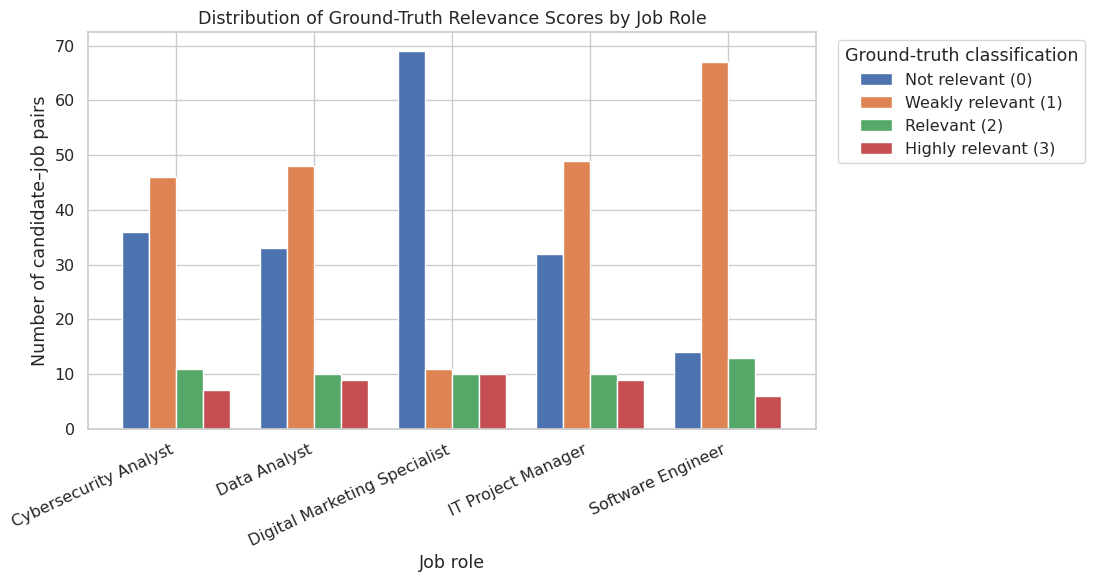

Saved: /content/Explainable_Candidate_Job_Matching_Level7/results/figures/ground_truth_distribution.png


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.05)

plot_distribution = pd.crosstab(
    final_ground_truth["job_title"],
    final_ground_truth["final_relevance_score"]
)

plot_distribution = plot_distribution.reindex(
    columns=[0, 1, 2, 3],
    fill_value=0
)

plot_distribution.columns = [
    "Not relevant (0)",
    "Weakly relevant (1)",
    "Relevant (2)",
    "Highly relevant (3)"
]

ax = plot_distribution.plot(
    kind="bar",
    figsize=(11, 6),
    width=0.78
)

ax.set_xlabel("Job role")
ax.set_ylabel("Number of candidate–job pairs")
ax.set_title("Distribution of Ground-Truth Relevance Scores by Job Role")
ax.legend(
    title="Ground-truth classification",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.xticks(rotation=25, ha="right")
plt.tight_layout()

figure1_path = (
    FOLDERS["figures"] /
    "ground_truth_distribution.png"
)

plt.savefig(
    figure1_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", figure1_path)

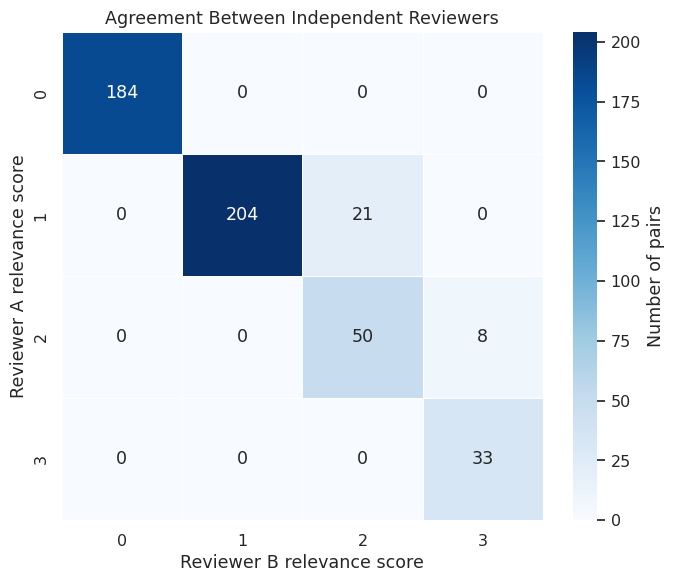

Saved: /content/Explainable_Candidate_Job_Matching_Level7/results/figures/reviewer_agreement_matrix.png


In [32]:
reviewer_matrix = pd.crosstab(
    merged_annotations[
        "relevance_score_0_to_3_reviewer_a"
    ].astype(int),
    merged_annotations[
        "relevance_score_0_to_3_reviewer_b"
    ].astype(int)
).reindex(
    index=[0, 1, 2, 3],
    columns=[0, 1, 2, 3],
    fill_value=0
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    reviewer_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar_kws={"label": "Number of pairs"},
    linewidths=0.5
)

plt.xlabel("Reviewer B relevance score")
plt.ylabel("Reviewer A relevance score")
plt.title("Agreement Between Independent Reviewers")
plt.tight_layout()

figure2_path = (
    FOLDERS["figures"] /
    "reviewer_agreement_matrix.png"
)

plt.savefig(
    figure2_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", figure2_path)

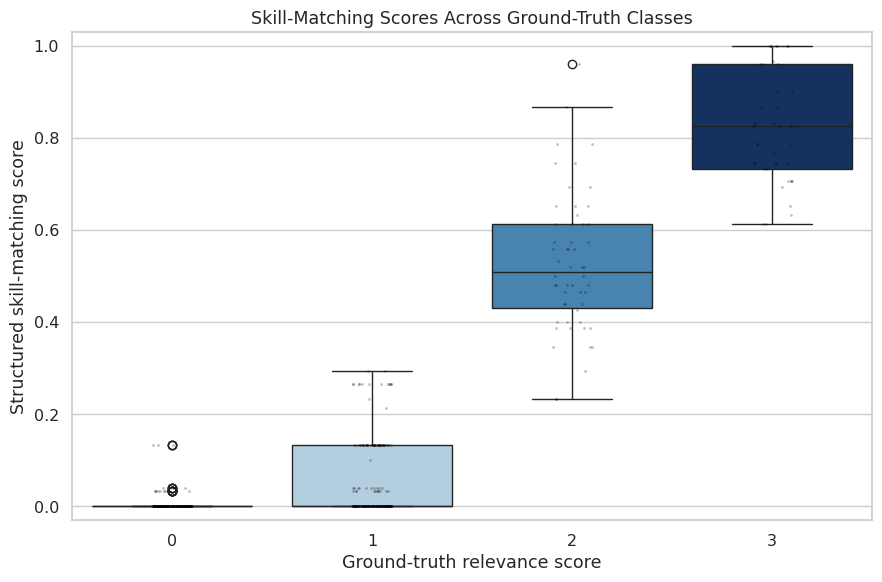

Saved: /content/Explainable_Candidate_Job_Matching_Level7/results/figures/skill_score_by_relevance.png


In [33]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=features_df,
    x="final_relevance_score",
    y="skill_score",
    hue="final_relevance_score",
    palette="Blues",
    legend=False
)

sns.stripplot(
    data=features_df,
    x="final_relevance_score",
    y="skill_score",
    color="black",
    alpha=0.25,
    size=2
)

plt.xlabel("Ground-truth relevance score")
plt.ylabel("Structured skill-matching score")
plt.title("Skill-Matching Scores Across Ground-Truth Classes")
plt.ylim(-0.03, 1.03)
plt.tight_layout()

figure3_path = (
    FOLDERS["figures"] /
    "skill_score_by_relevance.png"
)

plt.savefig(
    figure3_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", figure3_path)

In [34]:
from pathlib import Path

PROJECT_ROOT = Path(
    "/content/Explainable_Candidate_Job_Matching_Level7"
)

print("Project folder:", PROJECT_ROOT)
print("Folder exists:", PROJECT_ROOT.exists())

if PROJECT_ROOT.exists():
    project_files = list(PROJECT_ROOT.rglob("*"))
    print("Items found:", len(project_files))
else:
    print("The Colab runtime was restarted and temporary project files are unavailable.")

Project folder: /content/Explainable_Candidate_Job_Matching_Level7
Folder exists: True
Items found: 131


In [35]:
import json
import zipfile
from pathlib import Path
from google.colab import files, _message
from nbconvert import MarkdownExporter
from nbformat import reads

EXPORT_NAME = "Explainable_Candidate_Job_Matching_Level7"
EXPORT_FOLDER = Path("/content/Colab_Notebook_Export")

EXPORT_FOLDER.mkdir(
    parents=True,
    exist_ok=True
)

notebook_path = EXPORT_FOLDER / f"{EXPORT_NAME}.ipynb"
markdown_path = EXPORT_FOLDER / f"{EXPORT_NAME}.md"
assets_folder = EXPORT_FOLDER / f"{EXPORT_NAME}_files"
zip_path = Path("/content") / f"{EXPORT_NAME}.zip"

# -------------------------------------------------------
# Save the current notebook
# -------------------------------------------------------

print("Saving current Colab notebook...")

response = _message.blocking_request(
    "get_ipynb",
    timeout_sec=600
)

if "ipynb" not in response:
    raise RuntimeError(
        "Unable to access the notebook. "
        "Select File → Save, and then run this cell again."
    )

with open(notebook_path, "w", encoding="utf-8") as file:
    json.dump(
        response["ipynb"],
        file,
        ensure_ascii=False,
        indent=2
    )

print("IPYNB saved successfully.")

# -------------------------------------------------------
# Convert the notebook to Markdown
# -------------------------------------------------------

print("Converting notebook to Markdown...")

with open(notebook_path, "r", encoding="utf-8") as file:
    notebook_node = reads(
        file.read(),
        as_version=4
    )

exporter = MarkdownExporter()

markdown_text, resources = exporter.from_notebook_node(
    notebook_node
)

with open(markdown_path, "w", encoding="utf-8") as file:
    file.write(markdown_text)

# Save graphs and images extracted from notebook outputs
outputs = resources.get("outputs", {})

if outputs:
    assets_folder.mkdir(
        parents=True,
        exist_ok=True
    )

    for output_name, output_content in outputs.items():
        output_path = assets_folder / output_name

        output_path.parent.mkdir(
            parents=True,
            exist_ok=True
        )

        if isinstance(output_content, bytes):
            with open(output_path, "wb") as file:
                file.write(output_content)
        else:
            with open(
                output_path,
                "w",
                encoding="utf-8"
            ) as file:
                file.write(output_content)

print("Markdown saved successfully.")

# -------------------------------------------------------
# Create ZIP
# -------------------------------------------------------

if zip_path.exists():
    zip_path.unlink()

with zipfile.ZipFile(
    zip_path,
    "w",
    compression=zipfile.ZIP_DEFLATED
) as zip_file:

    for item in EXPORT_FOLDER.rglob("*"):
        if item.is_file():
            zip_file.write(
                item,
                item.relative_to(EXPORT_FOLDER)
            )

print("ZIP created successfully.")
print("ZIP size:", round(
    zip_path.stat().st_size / (1024 * 1024),
    2
), "MB")

# -------------------------------------------------------
# Download all formats
# -------------------------------------------------------

files.download(str(notebook_path))
files.download(str(markdown_path))
files.download(str(zip_path))

Saving current Colab notebook...
IPYNB saved successfully.
Converting notebook to Markdown...
Markdown saved successfully.
ZIP created successfully.
ZIP size: 0.29 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [36]:
print("connected")

connected


In [37]:
from sentence_transformers import SentenceTransformer
from rank_bm25 import BM25Okapi
import numpy as np
import pandas as pd
import re

# Check that the earlier cells completed correctly
assert len(features_df) == 500
assert final_ground_truth["candidate_id"].nunique() == 100
assert final_ground_truth["job_id"].nunique() == 5

pairs = final_ground_truth[
    ["candidate_id", "job_id", "job_title", "cv_text",
     "job_description", "final_relevance_score"]
].merge(
    features_df[["candidate_id", "job_id", "skill_score"]],
    on=["candidate_id", "job_id"],
    validate="one_to_one"
)

# Sentence-BERT: encode each distinct CV and job only once
model_name = CONFIG["sbert_model"]
model = SentenceTransformer(model_name)

cv_texts = pairs.drop_duplicates("candidate_id").set_index("candidate_id")["cv_text"]
job_texts = pairs.drop_duplicates("job_id").set_index("job_id")["job_description"]

cv_vectors = model.encode(
    cv_texts.tolist(), normalize_embeddings=True,
    convert_to_numpy=True, show_progress_bar=True
)
job_vectors = model.encode(
    job_texts.tolist(), normalize_embeddings=True,
    convert_to_numpy=True, show_progress_bar=True
)

cv_vector_by_id = dict(zip(cv_texts.index, cv_vectors))
job_vector_by_id = dict(zip(job_texts.index, job_vectors))

pairs["semantic_cosine"] = [
    float(np.dot(cv_vector_by_id[c], job_vector_by_id[j]))
    for c, j in zip(pairs["candidate_id"], pairs["job_id"])
]

# Convert cosine similarity from [-1, 1] to [0, 1]
pairs["semantic_score"] = (pairs["semantic_cosine"] + 1.0) / 2.0

# BM25 is fitted separately for each job's 100 candidate CVs
def tokenize(text):
    return re.findall(r"[a-z0-9]+", str(text).lower())

pairs["bm25_score"] = np.nan
for job_id, group in pairs.groupby("job_id", sort=False):
    corpus = [tokenize(text) for text in group["cv_text"]]
    bm25 = BM25Okapi(corpus)
    query = tokenize(group["job_description"].iloc[0])
    pairs.loc[group.index, "bm25_score"] = bm25.get_scores(query)

# The stated 60:40 design choice
pairs["hybrid_score"] = (
    CONFIG["semantic_weight"] * pairs["semantic_score"]
    + CONFIG["skill_weight"] * pairs["skill_score"]
)

assert len(pairs) == 500
assert pairs[["semantic_score", "skill_score",
              "bm25_score", "hybrid_score"]].notna().all().all()

scores_path = FOLDERS["experiments"] / "all_model_scores.csv"
pairs.to_csv(scores_path, index=False)

print("Model:", model_name)
print("Pairs scored:", len(pairs))
print("Weights:", CONFIG["semantic_weight"], CONFIG["skill_weight"])
print("Saved:", scores_path)
display(pairs[[
    "candidate_id", "job_id", "final_relevance_score",
    "semantic_score", "skill_score", "bm25_score", "hybrid_score"
]].head())

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Model: all-MiniLM-L6-v2
Pairs scored: 500
Weights: 0.6 0.4
Saved: /content/Explainable_Candidate_Job_Matching_Level7/experiments/all_model_scores.csv


,candidate_id,job_id,final_relevance_score,semantic_score,skill_score,bm25_score,hybrid_score
0,CAND001,JOB001,2,0.806016,0.653333,36.730237,0.744943
1,CAND001,JOB002,1,0.719302,0.133333,9.757436,0.484914
2,CAND001,JOB003,0,0.736838,0.000000,5.779156,0.442103
3,CAND001,JOB004,1,0.732297,0.133333,9.992714,0.492712
4,CAND001,JOB005,1,0.745524,0.000000,7.844591,0.447314


In [38]:
from sklearn.metrics import ndcg_score
import pandas as pd
import numpy as np

methods = {
    "BM25": "bm25_score",
    "Sentence-BERT": "semantic_score",
    "Skill only": "skill_score",
    "Hybrid 60:40": "hybrid_score"
}

results = []

for job_id, group in pairs.groupby("job_id", sort=True):
    # Same 100 candidates and ground-truth labels for every method
    group = group.sort_values("candidate_id").reset_index(drop=True)
    truth = group["final_relevance_score"].to_numpy(dtype=float)

    for method, score_column in methods.items():
        scores = group[score_column].to_numpy(dtype=float)

        # Stable candidate-ID order resolves any tied scores
        ranking = np.argsort(-scores, kind="stable")
        top5_truth = truth[ranking[:5]]

        results.append({
            "job_id": job_id,
            "job_title": group["job_title"].iloc[0],
            "method": method,
            "NDCG@5": ndcg_score(
                truth.reshape(1, -1),
                scores.reshape(1, -1),
                k=5
            ),
            "NDCG@10": ndcg_score(
                truth.reshape(1, -1),
                scores.reshape(1, -1),
                k=10
            ),
            # A relevance label of 2 or 3 counts as relevant
            "Precision@5": np.mean(top5_truth >= 2)
        })

results_df = pd.DataFrame(results)

summary_df = (
    results_df.groupby("method", as_index=False)[
        ["NDCG@5", "NDCG@10", "Precision@5"]
    ]
    .mean()
    .sort_values("NDCG@5", ascending=False)
)

results_path = FOLDERS["experiments"] / "ranking_results_by_job.csv"
summary_path = FOLDERS["experiments"] / "ranking_results_mean.csv"

results_df.to_csv(results_path, index=False)
summary_df.to_csv(summary_path, index=False)

print("PER-JOB RESULTS")
display(results_df.round(4))

print("MEAN ACROSS FIVE JOBS")
display(summary_df.round(4))

print("Saved:", results_path)
print("Saved:", summary_path)

PER-JOB RESULTS


,job_id,job_title,method,NDCG@5,NDCG@10,Precision@5
0,JOB001,Software Engineer,BM25,0.8304,0.9059,1.0
1,JOB001,Software Engineer,Sentence-BERT,0.8432,0.8605,1.0
2,JOB001,Software Engineer,Skill only,0.9781,0.9962,1.0
3,JOB001,Software Engineer,Hybrid 60:40,1.0000,0.9967,1.0
4,JOB002,Data Analyst,BM25,1.0000,0.9291,1.0
5,JOB002,Data Analyst,Sentence-BERT,0.9125,0.8934,0.8
6,JOB002,Data Analyst,Skill only,0.9287,0.9744,1.0
7,JOB002,Data Analyst,Hybrid 60:40,0.9287,0.9744,1.0
8,JOB003,Cybersecurity Analyst,BM25,0.9435,0.9834,1.0
9,JOB003,Cybersecurity Analyst,Sentence-BERT,0.8849,0.8457,1.0


MEAN ACROSS FIVE JOBS


,method,NDCG@5,NDCG@10,Precision@5
1,Hybrid 60:40,0.9770,0.9774,1.00
3,Skill only,0.9716,0.9811,1.00
0,BM25,0.9318,0.9393,1.00
2,Sentence-BERT,0.8896,0.8803,0.96


Saved: /content/Explainable_Candidate_Job_Matching_Level7/experiments/ranking_results_by_job.csv
Saved: /content/Explainable_Candidate_Job_Matching_Level7/experiments/ranking_results_mean.csv


In [39]:
import shutil
from google.colab import files

archive = shutil.make_archive(
    "/content/Explainable_Candidate_Job_Matching_Level7_results",
    "zip",
    root_dir="/content",
    base_dir="Explainable_Candidate_Job_Matching_Level7"
)

print("Created:", archive)
files.download(archive)

Created: /content/Explainable_Candidate_Job_Matching_Level7_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>